In [2]:
# 02_eda.ipynb - Детальний аналіз даних

import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from src.config import DATA_DIR, FIGURES_DIR
from src.data_loader import load_clicks, load_buys

# Налаштування візуалізації
%matplotlib inline

# Перевіряємо доступні стилі та вибираємо той, що є
available_styles = plt.style.available
print("Доступні стилі:", available_styles[:5])  # Показуємо перші 5

# Вибираємо стиль, який є в системі
if 'seaborn-v0_8' in available_styles:
    plt.style.use('seaborn-v0_8')
elif 'seaborn' in available_styles:
    plt.style.use('seaborn')
elif 'ggplot' in available_styles:
    plt.style.use('ggplot')
else:
    plt.style.use('default')  # стандартний стиль

# Налаштовуємо кольорову палітру
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Створюємо папку для збереження графіків EDA
(FIGURES_DIR / 'eda').mkdir(parents=True, exist_ok=True)

print("\n" + "="*60)
print("АНАЛІЗ ДАНИХ YOOCHOOSE")
print("="*60)

Доступні стилі: ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh']

АНАЛІЗ ДАНИХ YOOCHOOSE


In [3]:
# Завантаження даних
print("Завантаження даних...")
clicks = load_clicks()
buys = load_buys()

print(f"\n✅ Clicks: {len(clicks):,} записів")
print(f"✅ Buys: {len(buys):,} записів")
print(f"✅ Унікальних сесій: {clicks['Session_ID'].nunique():,}")
print(f"✅ Унікальних товарів: {clicks['Item_ID'].nunique():,}")
print(f"✅ Унікальних категорій: {clicks['Category'].nunique():,}")

# Базова інформація
print("\n" + "="*60)
print("ІНФОРМАЦІЯ ПРО ДАНІ")
print("="*60)
print("\nClicks info:")
print(clicks.info())

Завантаження даних...

✅ Clicks: 33,003,944 записів
✅ Buys: 1,150,753 записів
✅ Унікальних сесій: 9,249,729
✅ Унікальних товарів: 52,739
✅ Унікальних категорій: 339

ІНФОРМАЦІЯ ПРО ДАНІ

Clicks info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33003944 entries, 0 to 33003943
Data columns (total 4 columns):
 #   Column      Dtype              
---  ------      -----              
 0   Session_ID  int64              
 1   Timestamp   datetime64[ns, UTC]
 2   Item_ID     int64              
 3   Category    object             
dtypes: datetime64[ns, UTC](1), int64(2), object(1)
memory usage: 1007.2+ MB
None


In [4]:
print("="*60)
print("ЯКІСТЬ ДАНИХ")
print("="*60)

# Пропущені значення
print("\n📊 Пропущені значення:")
print(f"Clicks: {clicks.isnull().sum().sum()} пропусків")
print(f"Buys: {buys.isnull().sum().sum()} пропусків")

# Дублікати
print(f"\n📊 Дублікати:")
print(f"Clicks: {clicks.duplicated().sum():,} дублікатів")
print(f"Buys: {buys.duplicated().sum():,} дублікатів")

# Видаляємо дублікати якщо є
if clicks.duplicated().sum() > 0:
    clicks = clicks.drop_duplicates()
    print(f"\n✅ Видалено дублікати з clicks")

if buys.duplicated().sum() > 0:
    buys = buys.drop_duplicates()
    print(f"✅ Видалено дублікати з buys")

ЯКІСТЬ ДАНИХ

📊 Пропущені значення:
Clicks: 0 пропусків
Buys: 0 пропусків

📊 Дублікати:
Clicks: 68 дублікатів
Buys: 146 дублікатів

✅ Видалено дублікати з clicks
✅ Видалено дублікати з buys


АНАЛІЗ ДОВЖИНИ СЕСІЙ

Статистика довжини сесій:
  Середня: 3.57
  Медіана: 2.00
  Мінімум: 1
  Максимум: 200
  25-й перцентиль: 2.00
  75-й перцентиль: 4.00
  95-й перцентиль: 9.00
  99-й перцентиль: 18.00


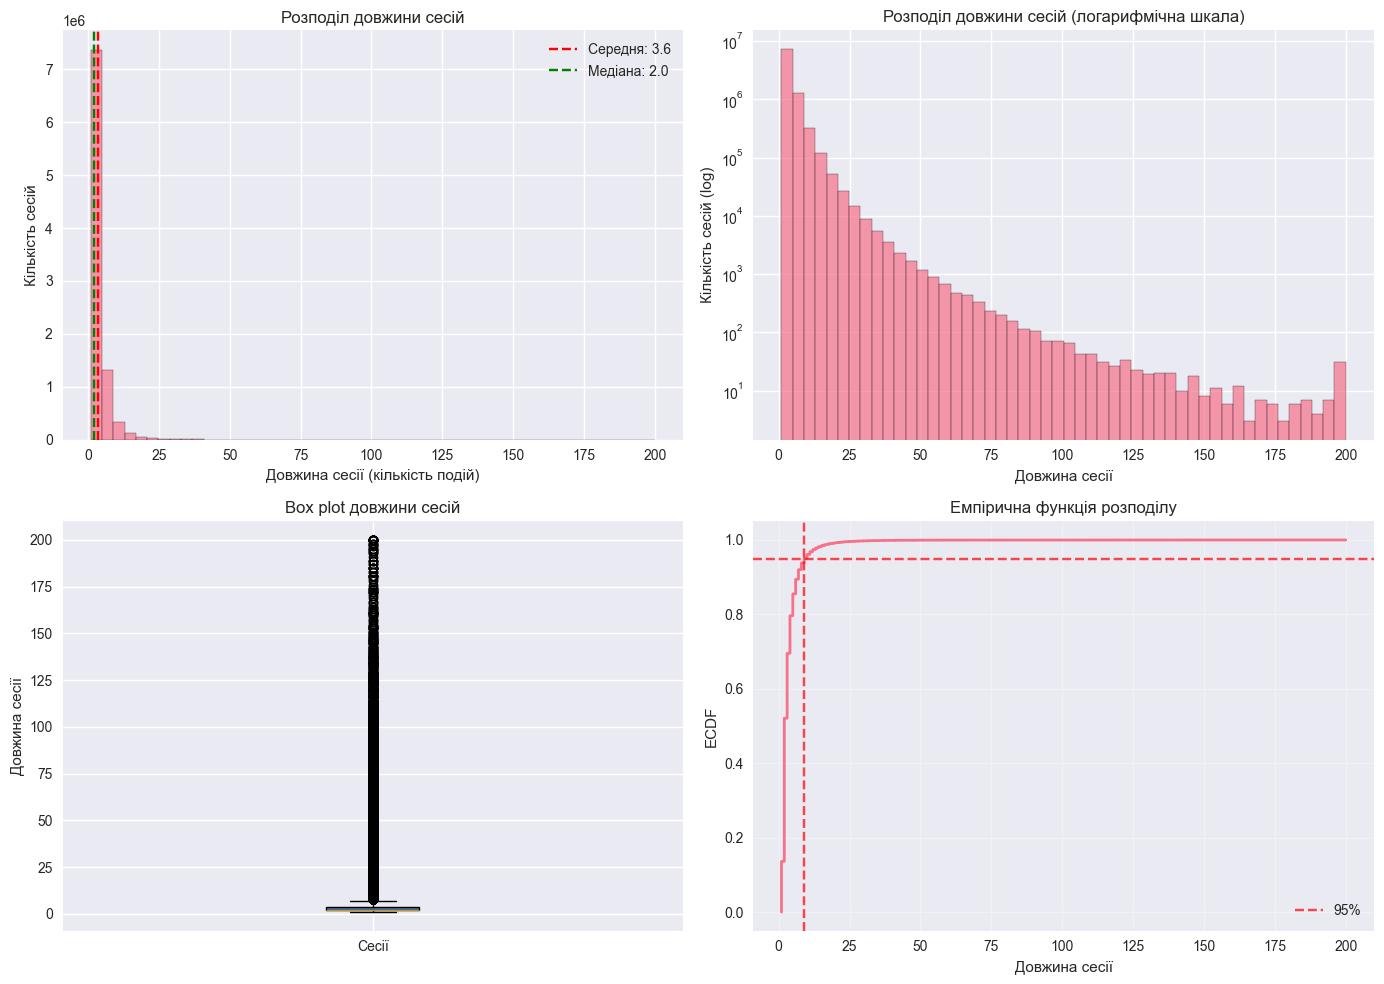

In [5]:
print("="*60)
print("АНАЛІЗ ДОВЖИНИ СЕСІЙ")
print("="*60)

# Розрахунок довжини сесій
session_lengths = clicks.groupby('Session_ID').size()

print(f"\nСтатистика довжини сесій:")
print(f"  Середня: {session_lengths.mean():.2f}")
print(f"  Медіана: {session_lengths.median():.2f}")
print(f"  Мінімум: {session_lengths.min()}")
print(f"  Максимум: {session_lengths.max()}")
print(f"  25-й перцентиль: {session_lengths.quantile(0.25):.2f}")
print(f"  75-й перцентиль: {session_lengths.quantile(0.75):.2f}")
print(f"  95-й перцентиль: {session_lengths.quantile(0.95):.2f}")
print(f"  99-й перцентиль: {session_lengths.quantile(0.99):.2f}")

# Візуалізація
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Гістограма
session_lengths.hist(bins=50, ax=axes[0,0], edgecolor='black', alpha=0.7)
axes[0,0].set_title('Розподіл довжини сесій')
axes[0,0].set_xlabel('Довжина сесії (кількість подій)')
axes[0,0].set_ylabel('Кількість сесій')
axes[0,0].axvline(session_lengths.mean(), color='red', linestyle='--', label=f'Середня: {session_lengths.mean():.1f}')
axes[0,0].axvline(session_lengths.median(), color='green', linestyle='--', label=f'Медіана: {session_lengths.median():.1f}')
axes[0,0].legend()

# Логарифмічна шкала
session_lengths.hist(bins=50, ax=axes[0,1], log=True, edgecolor='black', alpha=0.7)
axes[0,1].set_title('Розподіл довжини сесій (логарифмічна шкала)')
axes[0,1].set_xlabel('Довжина сесії')
axes[0,1].set_ylabel('Кількість сесій (log)')

# Box plot
bp = axes[1,0].boxplot(session_lengths, vert=True, patch_artist=True)
axes[1,0].set_title('Box plot довжини сесій')
axes[1,0].set_ylabel('Довжина сесії')
axes[1,0].set_xticklabels(['Сесії'])

# ECDF (емпірична функція розподілу)
sorted_lengths = np.sort(session_lengths)
ecdf = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths)
axes[1,1].plot(sorted_lengths, ecdf, linewidth=2)
axes[1,1].set_title('Емпірична функція розподілу')
axes[1,1].set_xlabel('Довжина сесії')
axes[1,1].set_ylabel('ECDF')
axes[1,1].grid(True, alpha=0.3)
axes[1,1].axhline(0.95, color='red', linestyle='--', alpha=0.7, label='95%')
axes[1,1].axvline(session_lengths.quantile(0.95), color='red', linestyle='--', alpha=0.7)
axes[1,1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda/session_length_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

АНАЛІЗ ПОКУПОК

📈 Статистика конверсії:
  Всього сесій: 9,249,729
  Сесій з покупками: 509,696
  Сесій без покупок: 8,740,033
  Конверсія: 5.51%

📊 Довжина сесій:
  Середня довжина сесій з покупкою: 6.49
  Середня довжина сесій без покупки: 3.40


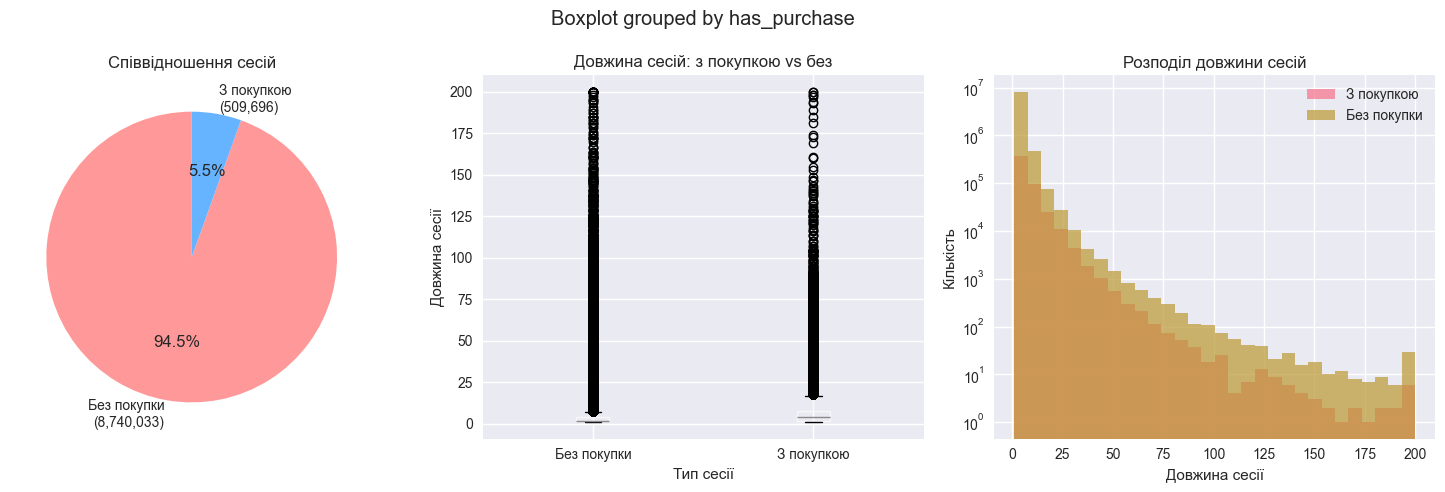

In [6]:
print("="*60)
print("АНАЛІЗ ПОКУПОК")
print("="*60)

# Сесії з покупками
sessions_with_buys = buys['Session_ID'].unique() if len(buys) > 0 else []
clicks['has_purchase'] = clicks['Session_ID'].isin(sessions_with_buys)

# Статистика
n_sessions_total = clicks['Session_ID'].nunique()
n_sessions_with_buys = len(sessions_with_buys)
n_sessions_without_buys = n_sessions_total - n_sessions_with_buys
conversion_rate = n_sessions_with_buys / n_sessions_total * 100

print(f"\n📈 Статистика конверсії:")
print(f"  Всього сесій: {n_sessions_total:,}")
print(f"  Сесій з покупками: {n_sessions_with_buys:,}")
print(f"  Сесій без покупок: {n_sessions_without_buys:,}")
print(f"  Конверсія: {conversion_rate:.2f}%")

# Довжина сесій для різних типів
session_stats = clicks.groupby('Session_ID').agg({
    'has_purchase': 'first',
    'Item_ID': 'count'
}).rename(columns={'Item_ID': 'length'})

print(f"\n📊 Довжина сесій:")
print(f"  Середня довжина сесій з покупкою: {session_stats[session_stats['has_purchase']]['length'].mean():.2f}")
print(f"  Середня довжина сесій без покупки: {session_stats[~session_stats['has_purchase']]['length'].mean():.2f}")

# Візуалізація
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Pie chart
colors = ['#ff9999', '#66b3ff']
labels = [f'Без покупки\n({n_sessions_without_buys:,})', f'З покупкою\n({n_sessions_with_buys:,})']
axes[0].pie([n_sessions_without_buys, n_sessions_with_buys], labels=labels, 
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Співвідношення сесій')

# Box plot
session_stats.boxplot(column='length', by='has_purchase', ax=axes[1])
axes[1].set_title('Довжина сесій: з покупкою vs без')
axes[1].set_xlabel('Тип сесії')
axes[1].set_ylabel('Довжина сесії')
axes[1].set_xticklabels(['Без покупки', 'З покупкою'])

# Гістограма
session_stats[session_stats['has_purchase']]['length'].hist(bins=30, alpha=0.7, label='З покупкою', ax=axes[2])
session_stats[~session_stats['has_purchase']]['length'].hist(bins=30, alpha=0.7, label='Без покупки', ax=axes[2])
axes[2].set_title('Розподіл довжини сесій')
axes[2].set_xlabel('Довжина сесії')
axes[2].set_ylabel('Кількість')
axes[2].legend()
axes[2].set_yscale('log')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda/purchase_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

ЧАСОВИЙ АНАЛІЗ

📅 Часовий діапазон даних:
  Початок: 2014-04-01 03:00:00.124000+00:00
  Кінець: 2014-09-30 02:59:59.430000+00:00
  Тривалість: 181 days 23:59:59.306000

⏰ Пікова година: 19:00 (2,562,232 подій)

📆 Піковий день: Неділя (7,360,071 подій)


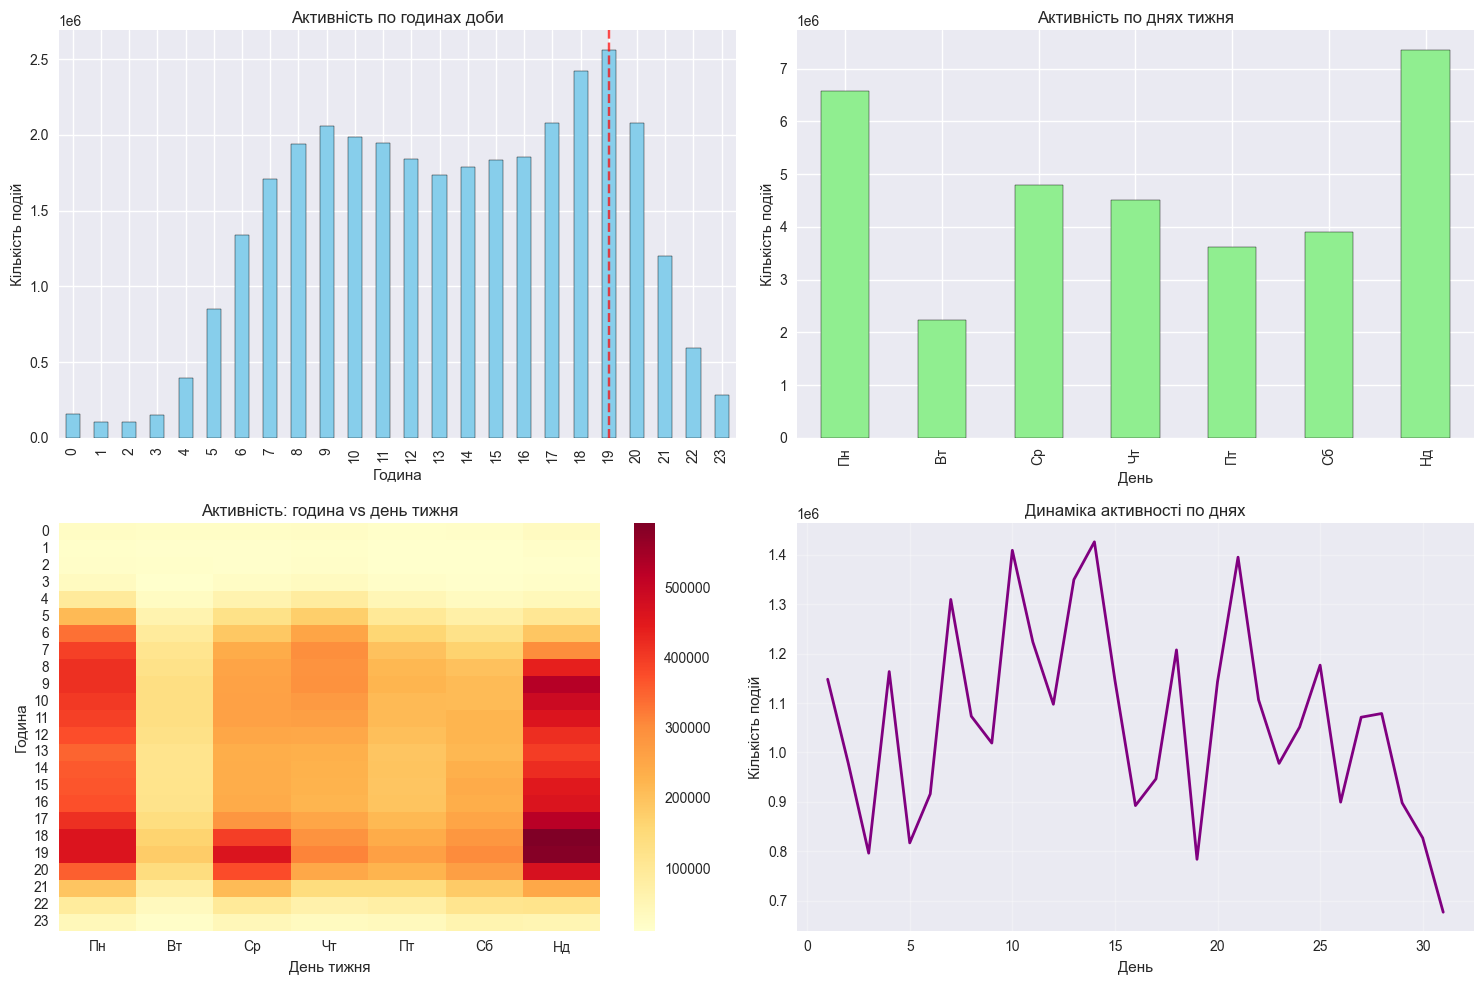

In [7]:
print("="*60)
print("ЧАСОВИЙ АНАЛІЗ")
print("="*60)

# Додаємо часові ознаки
clicks['hour'] = clicks['Timestamp'].dt.hour
clicks['dayofweek'] = clicks['Timestamp'].dt.dayofweek
clicks['month'] = clicks['Timestamp'].dt.month
clicks['day'] = clicks['Timestamp'].dt.day

# Часовий діапазон
print(f"\n📅 Часовий діапазон даних:")
print(f"  Початок: {clicks['Timestamp'].min()}")
print(f"  Кінець: {clicks['Timestamp'].max()}")
print(f"  Тривалість: {clicks['Timestamp'].max() - clicks['Timestamp'].min()}")

# Активність по годинах
hourly_activity = clicks.groupby('hour').size()
peak_hour = hourly_activity.idxmax()
print(f"\n⏰ Пікова година: {peak_hour}:00 ({hourly_activity.max():,} подій)")

# Активність по днях
daily_activity = clicks.groupby('dayofweek').size()
peak_day = daily_activity.idxmax()
days_names = ['Понеділок', 'Вівторок', 'Середа', 'Четвер', "П'ятниця", 'Субота', 'Неділя']
print(f"\n📆 Піковий день: {days_names[peak_day]} ({daily_activity.max():,} подій)")

# Візуалізація
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# По годинах
hourly_activity.plot(kind='bar', ax=axes[0,0], color='skyblue', edgecolor='black')
axes[0,0].set_title('Активність по годинах доби')
axes[0,0].set_xlabel('Година')
axes[0,0].set_ylabel('Кількість подій')
axes[0,0].axvline(peak_hour, color='red', linestyle='--', alpha=0.7)

# По днях тижня
daily_activity.index = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Нд']
daily_activity.plot(kind='bar', ax=axes[0,1], color='lightgreen', edgecolor='black')
axes[0,1].set_title('Активність по днях тижня')
axes[0,1].set_xlabel('День')
axes[0,1].set_ylabel('Кількість подій')

# Теплова карта: година vs день тижня
pivot_table = clicks.pivot_table(
    index='hour', 
    columns='dayofweek', 
    values='Session_ID', 
    aggfunc='count',
    fill_value=0
)
sns.heatmap(pivot_table, ax=axes[1,0], cmap='YlOrRd', annot=False, fmt='d')
axes[1,0].set_title('Активність: година vs день тижня')
axes[1,0].set_xlabel('День тижня')
axes[1,0].set_ylabel('Година')
axes[1,0].set_xticklabels(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Нд'])

# Динаміка по днях (якщо більше 30 днів)
if clicks['day'].nunique() > 30:
    daily_trend = clicks.groupby('day').size()
    daily_trend.plot(ax=axes[1,1], color='purple', linewidth=2)
    axes[1,1].set_title('Динаміка активності по днях')
    axes[1,1].set_xlabel('День')
    axes[1,1].set_ylabel('Кількість подій')
    axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda/temporal_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

АНАЛІЗ ТОВАРІВ ТА КАТЕГОРІЙ

📦 Топ-10 найпопулярніших товарів:
  1. Товар 643078800: 147,419 переглядів
  2. Товар 214853094: 125,690 переглядів
  3. Товар 214829878: 113,488 переглядів
  4. Товар 214853420: 78,448 переглядів
  5. Товар 214826610: 69,710 переглядів
  6. Товар 214853096: 66,067 переглядів
  7. Товар 214748336: 62,150 переглядів
  8. Товар 214834880: 61,668 переглядів
  9. Товар 214839973: 60,332 переглядів
  10. Товар 214821309: 55,854 переглядів

🏷️ Топ-10 найпопулярніших категорій:
  1. Категорія 0: 16,337,622 переглядів
  2. Категорія S: 10,769,579 переглядів
  3. Категорія 1: 1,671,754 переглядів
  4. Категорія 2: 1,292,246 переглядів
  5. Категорія 3: 789,713 переглядів
  6. Категорія 4: 480,569 переглядів
  7. Категорія 5: 471,922 переглядів
  8. Категорія 6: 414,696 переглядів
  9. Категорія 7: 389,910 переглядів
  10. Категорія 9: 105,282 переглядів


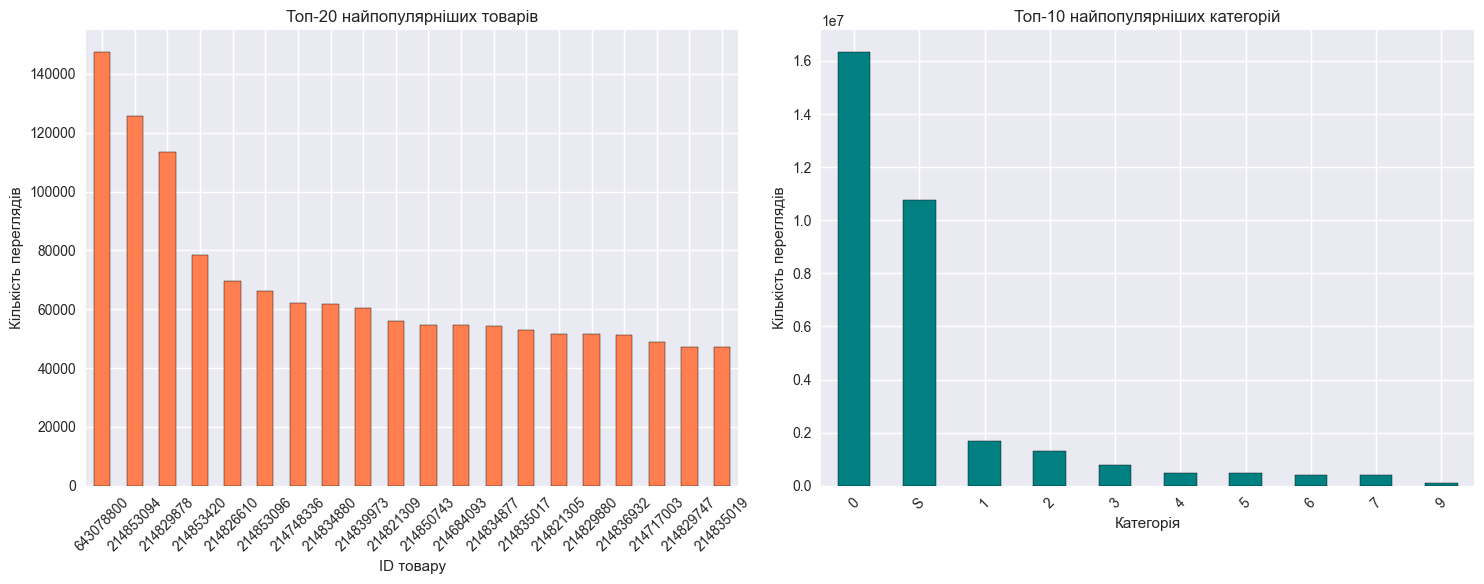

In [8]:
print("="*60)
print("АНАЛІЗ ТОВАРІВ ТА КАТЕГОРІЙ")
print("="*60)

# Топ товарів
top_items = clicks['Item_ID'].value_counts().head(20)

print(f"\n📦 Топ-10 найпопулярніших товарів:")
for i, (item_id, count) in enumerate(top_items.head(10).items(), 1):
    print(f"  {i}. Товар {item_id}: {count:,} переглядів")

# Топ категорій
top_categories = clicks['Category'].value_counts().head(10)

print(f"\n🏷️ Топ-10 найпопулярніших категорій:")
for i, (cat, count) in enumerate(top_categories.head(10).items(), 1):
    print(f"  {i}. Категорія {cat}: {count:,} переглядів")

# Візуалізація
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Топ товарів
top_items.plot(kind='bar', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('Топ-20 найпопулярніших товарів')
axes[0].set_xlabel('ID товару')
axes[0].set_ylabel('Кількість переглядів')
axes[0].tick_params(axis='x', rotation=45)

# Топ категорій
top_categories.plot(kind='bar', ax=axes[1], color='teal', edgecolor='black')
axes[1].set_title('Топ-10 найпопулярніших категорій')
axes[1].set_xlabel('Категорія')
axes[1].set_ylabel('Кількість переглядів')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda/top_items_categories.png', dpi=100, bbox_inches='tight')
plt.show()

АНАЛІЗ ПОСЛІДОВНОСТЕЙ

📊 Перші кліки в сесії:
  Середній час першого кліку: 13.2:00
  Найчастіший час першого кліку: 19:00

📊 Останні кліки в сесії:
  Середній час останнього кліку: 13.3:00
  Найчастіший час останнього кліку: 19:00


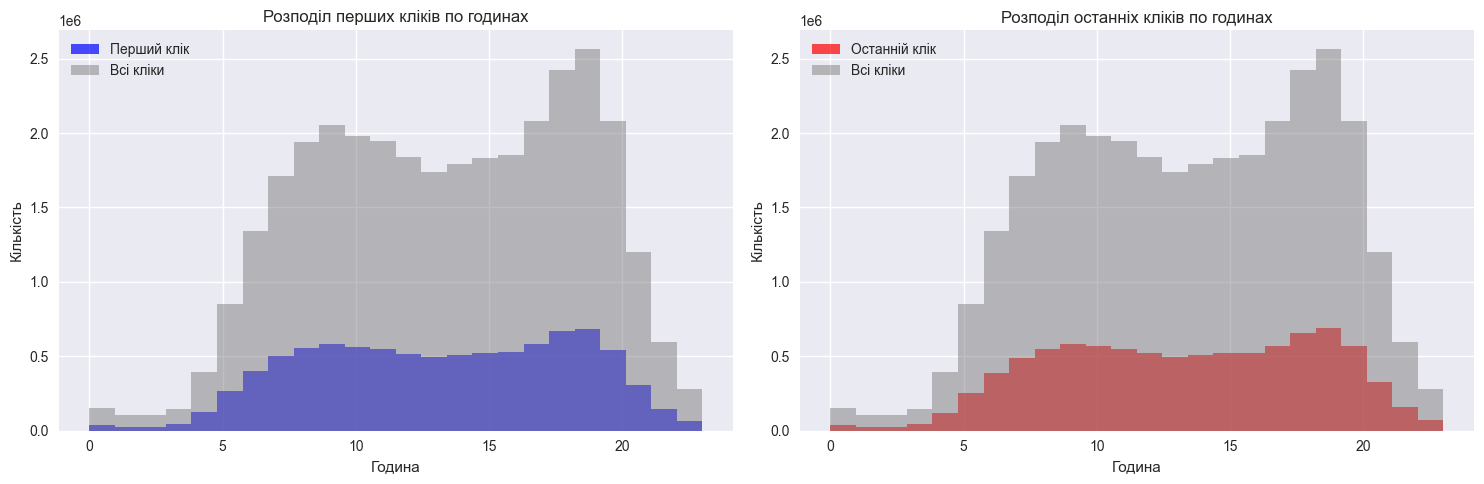

In [9]:
print("="*60)
print("АНАЛІЗ ПОСЛІДОВНОСТЕЙ")
print("="*60)

# Аналіз перших кліків
first_clicks = clicks.groupby('Session_ID').first().reset_index()
last_clicks = clicks.groupby('Session_ID').last().reset_index()

print(f"\n📊 Перші кліки в сесії:")
print(f"  Середній час першого кліку: {first_clicks['hour'].mean():.1f}:00")
print(f"  Найчастіший час першого кліку: {first_clicks['hour'].mode()[0]}:00")

print(f"\n📊 Останні кліки в сесії:")
print(f"  Середній час останнього кліку: {last_clicks['hour'].mean():.1f}:00")
print(f"  Найчастіший час останнього кліку: {last_clicks['hour'].mode()[0]}:00")

# Візуалізація
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Перші кліки
first_clicks['hour'].hist(bins=24, ax=axes[0], alpha=0.7, label='Перший клік', color='blue')
clicks['hour'].hist(bins=24, ax=axes[0], alpha=0.5, label='Всі кліки', color='gray')
axes[0].set_title('Розподіл перших кліків по годинах')
axes[0].set_xlabel('Година')
axes[0].set_ylabel('Кількість')
axes[0].legend()

# Останні кліки
last_clicks['hour'].hist(bins=24, ax=axes[1], alpha=0.7, label='Останній клік', color='red')
clicks['hour'].hist(bins=24, ax=axes[1], alpha=0.5, label='Всі кліки', color='gray')
axes[1].set_title('Розподіл останніх кліків по годинах')
axes[1].set_xlabel('Година')
axes[1].set_ylabel('Кількість')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda/first_last_clicks.png', dpi=100, bbox_inches='tight')
plt.show()

In [10]:
print("="*60)
print("АНАЛІЗ АНОМАЛІЙ")
print("="*60)

# Знаходимо аномальні сесії (за довжиною)
q1 = session_lengths.quantile(0.25)
q3 = session_lengths.quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 3 * iqr  # використовуємо 3*IQR для аномалій

anomalous_sessions = session_lengths[session_lengths > upper_bound]

print(f"\n⚠️ Аномальні сесії:")
print(f"  Кількість аномальних сесій: {len(anomalous_sessions):,}")
print(f"  Відсоток від загалу: {len(anomalous_sessions)/len(session_lengths)*100:.2f}%")
print(f"  Мінімальна довжина аномальної сесії: {anomalous_sessions.min():.0f}")
print(f"  Максимальна довжина: {anomalous_sessions.max():.0f}")

# Аномалії за часом
if len(clicks) > 0:
    click_durations = clicks.groupby('Session_ID').agg({
        'Timestamp': lambda x: (x.max() - x.min()).total_seconds() / 60  # в хвилинах
    }).rename(columns={'Timestamp': 'duration'})
    
    # Фільтруємо сесії з більш ніж 1 подією
    click_durations = click_durations[click_durations['duration'] > 0]
    
    if len(click_durations) > 0:
        q1_dur = click_durations['duration'].quantile(0.25)
        q3_dur = click_durations['duration'].quantile(0.75)
        iqr_dur = q3_dur - q1_dur
        upper_bound_dur = q3_dur + 3 * iqr_dur
        
        anomalous_duration = click_durations[click_durations['duration'] > upper_bound_dur]
        
        print(f"\n⏱️ Аномально довгі сесії за часом:")
        print(f"  Кількість: {len(anomalous_duration):,}")
        print(f"  Середня тривалість аномальних: {anomalous_duration['duration'].mean():.1f} хв")
        print(f"  Максимальна тривалість: {anomalous_duration['duration'].max():.1f} хв")

АНАЛІЗ АНОМАЛІЙ

⚠️ Аномальні сесії:
  Кількість аномальних сесій: 359,960
  Відсоток від загалу: 3.89%
  Мінімальна довжина аномальної сесії: 11
  Максимальна довжина: 200

⏱️ Аномально довгі сесії за часом:
  Кількість: 495,425
  Середня тривалість аномальних: 47.7 хв
  Максимальна тривалість: 4099.0 хв


In [11]:
print("="*60)
print("ЗБЕРЕЖЕННЯ РЕЗУЛЬТАТІВ")
print("="*60)

# Зберігаємо важливі метрики
eda_results = {
    'total_sessions': int(clicks['Session_ID'].nunique()),
    'total_clicks': int(len(clicks)),
    'total_buys': int(len(buys)),
    'avg_session_length': float(session_lengths.mean()),
    'median_session_length': float(session_lengths.median()),
    'max_session_length': int(session_lengths.max()),
    'sessions_with_purchase': int(n_sessions_with_buys),
    'sessions_without_purchase': int(n_sessions_without_buys),
    'conversion_rate': float(conversion_rate),
    'peak_hour': int(peak_hour),
    'peak_day': str(days_names[peak_day]),
    'avg_clicks_per_session': float(clicks.groupby('Session_ID').size().mean()),
    'unique_items': int(clicks['Item_ID'].nunique()),
    'unique_categories': int(clicks['Category'].nunique()),
    'date_range_start': str(clicks['Timestamp'].min()),
    'date_range_end': str(clicks['Timestamp'].max()),
    'anomalous_sessions_count': int(len(anomalous_sessions)),
    'anomalous_sessions_percentage': float(len(anomalous_sessions)/len(session_lengths)*100)
}

import json
with open(DATA_DIR / 'eda_results.json', 'w', encoding='utf-8') as f:
    json.dump(eda_results, f, indent=4, ensure_ascii=False)

print("\n✅ Результати EDA збережено в:")
print(f"   - data/yoochoose/eda_results.json")
print(f"   - figures/eda/ (всі графіки)")

print("\n" + "="*60)
print("ПІДСУМКИ EDA")
print("="*60)

for key, value in eda_results.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.2f}")
    else:
        print(f"  {key}: {value}")

ЗБЕРЕЖЕННЯ РЕЗУЛЬТАТІВ

✅ Результати EDA збережено в:
   - data/yoochoose/eda_results.json
   - figures/eda/ (всі графіки)

ПІДСУМКИ EDA
  total_sessions: 9249729
  total_clicks: 33003876
  total_buys: 1150607
  avg_session_length: 3.57
  median_session_length: 2.00
  max_session_length: 200
  sessions_with_purchase: 509696
  sessions_without_purchase: 8740033
  conversion_rate: 5.51
  peak_hour: 19
  peak_day: Неділя
  avg_clicks_per_session: 3.57
  unique_items: 52739
  unique_categories: 339
  date_range_start: 2014-04-01 03:00:00.124000+00:00
  date_range_end: 2014-09-30 02:59:59.430000+00:00
  anomalous_sessions_count: 359960
  anomalous_sessions_percentage: 3.89


In [12]:
print("\n" + "="*60)
print("КЛЮЧОВІ ВИСНОВКИ З EDA")
print("="*60)

print("""
1. РОЗПОДІЛ СЕСІЙ:
   - Більшість сесій короткі (медіана {} подій)
   - Є довгі "хвости" - сесії з багатьма подіями
   - {}% сесій містять покупки

2. ЧАСОВІ ПАТЕРНИ:
   - Пікова активність: {}:00
   - Найактивніший день: {}
   - Чіткий добовий цикл активності

3. ПОВЕДІНКА КОРИСТУВАЧІВ:
   - Сесії з покупками в середньому довші
   - Перші кліки частіше в ранкові години
   - Останні кліки - ввечері

4. АНОМАЛІЇ:
   - {} сесій ({:.1f}%) є аномально довгими
   - Потребують додаткового аналізу

5. РЕКОМЕНДАЦІЇ ДЛЯ МОДЕЛІ:
   - Використовувати максимальну довжину сесії = {}
   - Враховувати часові ознаки
   - Балансувати класи (дисбаланс {:.1f}% / {:.1f}%)
""".format(
    int(eda_results['median_session_length']),
    round(eda_results['conversion_rate'], 1),
    eda_results['peak_hour'],
    eda_results['peak_day'],
    eda_results['anomalous_sessions_count'],
    eda_results['anomalous_sessions_percentage'],
    int(eda_results['avg_session_length']) * 2,
    eda_results['conversion_rate'],
    100 - eda_results['conversion_rate']
))

print("\n✅ EDA завершено! Можна переходити до 03_labeling.ipynb")


КЛЮЧОВІ ВИСНОВКИ З EDA

1. РОЗПОДІЛ СЕСІЙ:
   - Більшість сесій короткі (медіана 2 подій)
   - Є довгі "хвости" - сесії з багатьма подіями
   - 5.5% сесій містять покупки

2. ЧАСОВІ ПАТЕРНИ:
   - Пікова активність: 19:00
   - Найактивніший день: Неділя
   - Чіткий добовий цикл активності

3. ПОВЕДІНКА КОРИСТУВАЧІВ:
   - Сесії з покупками в середньому довші
   - Перші кліки частіше в ранкові години
   - Останні кліки - ввечері

4. АНОМАЛІЇ:
   - 359960 сесій (3.9%) є аномально довгими
   - Потребують додаткового аналізу

5. РЕКОМЕНДАЦІЇ ДЛЯ МОДЕЛІ:
   - Використовувати максимальну довжину сесії = 6
   - Враховувати часові ознаки
   - Балансувати класи (дисбаланс 5.5% / 94.5%)


✅ EDA завершено! Можна переходити до 03_labeling.ipynb
